# Multi-Agent Notebook Prototype

This notebook is a separate prototype for the **Multi-Agent Notebooks** idea from the course notes. Instead of a single assistant, it runs a small council of specialized agents over the same shared analytical state.

This version is **purely AI-based**. It requires a live Hugging Face OpenAI-compatible endpoint configured through `.env`, and every council response is generated by that model.

The five agents are:
- **Analyst**: identifies the highest-value next analytical slice
- **Critic**: challenges overconfident claims and requests robustness checks
- **Reproducer**: checks reproducibility and execution discipline
- **Writer**: drafts narrative text for the notebook
- **Reviewer**: prioritizes the next notebook edits

The notebook also uses a small styled presentation layer so the interaction reads like a product prototype rather than raw notebook plumbing.

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

repo_root = Path.cwd().resolve()
for candidate in (repo_root, *repo_root.parents):
    if (candidate / "pyproject.toml").exists() and (candidate / "prototypes").exists():
        repo_root = candidate
        break
else:
    raise RuntimeError("Could not locate the repository root.")

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

prototype_dir = repo_root / "prototypes" / "multi_agent_notebook"

from prototypes.shared.hf_openai_client import HuggingFaceOpenAIClient, endpoint_status_rows
from prototypes.shared.notebook_ui import agent_cards, callout, hero, inject_theme, metric_cards
from prototypes.multi_agent_notebook.multi_agent_notebook_support import (
    MultiAgentNotebookPrototype,
    notebook_fingerprint,
    overview_table,
    planned_notebook_cells,
    prepare_customer_health_data,
    priority_board,
    turns_to_frame,
    writer_note,
)

warnings.filterwarnings("ignore")
sns.set_theme(context="talk", style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (14, 6)
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 140)

In [2]:
display(inject_theme())
display(hero(
    "Multi-Agent Notebook Council",
    "A shared notebook state interpreted by five specialized roles, all generated through the live Hugging Face OpenAI-compatible model configured in the repository root .env.",
    pills=["Analyst", "Critic", "Reproducer", "Writer", "Reviewer"],
))

SEED = 42
customers = prepare_customer_health_data(seed=SEED)
live_client = HuggingFaceOpenAIClient.from_env(start_path=repo_root)
if live_client is None:
    raise RuntimeError("No valid Hugging Face OpenAI-compatible endpoint configuration was found in the repository root .env.")

prototype = MultiAgentNotebookPrototype(client=live_client)
endpoint_status = pd.DataFrame(endpoint_status_rows(start_path=repo_root, validate_connection=True))

display(metric_cards([
    {"title": "Council mode", "value": "Live AI", "note": "Every council response in this notebook is produced by the configured model."},
    {"title": "Rows", "value": f"{len(customers):,}", "note": "Shared analytical state seen by every agent."},
    {"title": "Churn rate", "value": f"{customers['is_churned'].mean():.1%}", "note": "Synthetic customer-health outcome rate."},
    {"title": "Revenue at risk", "value": f"${customers['revenue_at_risk'].sum():,.0f}", "note": "Headline business risk before the council starts reasoning."},
]))
display(callout(
    "Where the UI lives",
    "The hero banner, cards, callouts, and agent panels come from prototypes/shared/notebook_ui.py. You only see them in the rendered notebook view, not in the raw .ipynb JSON.",
    tone="info",
))
display(callout(
    "Notebook behavior",
    "This notebook is AI-only. If the endpoint is unavailable or misconfigured, execution stops until the live endpoint configuration is fixed.",
    tone="warn",
))
display(endpoint_status)
display(overview_table(customers))
display(notebook_fingerprint(customers, seed=SEED))

,field,value
0,status,configured
1,base_url,https://router.huggingface.co/v1
2,model,google/gemma-4-31B-it
3,api_key,hf_k...WQsX
4,env_file,/home/yunus/uni/piis/.env
5,connection,endpoint ok


,metric,value
0,Rows,"2,200"
1,Churn rate,2.5%
2,Average MRR,$865
3,Revenue at risk,"$15,863"
4,Median health score,63.8
5,Missing NPS share,5.0%
6,Missing usage growth share,3.0%


,attribute,value
0,seed,42.0000
1,rows,2200.0000
2,columns,25.0000
3,churn_rate,0.0245
4,revenue_at_risk,15863.0700
5,avg_health_score,64.9900


## Shared Notebook State

A multi-agent notebook only works if all agents reason over the same underlying state. In this prototype, that shared state is the customer-health dataframe plus a few shared summaries that every agent can inspect and debate.

The first set of plots exposes the same common evidence to every agent before any recommendations are made.

,slice_label,customers,churn_rate,avg_health_score,revenue_at_risk
1,Enterprise | Organic,59,0.00,88.38,0.00
3,Enterprise | Paid Search,88,0.00,90.57,0.00
9,Mid-Market | Partner,134,0.01,74.44,735.17
5,Mid-Market | Community,109,0.01,79.26,1053.33
10,SMB | Community,202,0.02,54.30,1249.18
11,SMB | Organic,237,0.03,53.97,1376.82
6,Mid-Market | Organic,116,0.02,74.32,1913.30
13,SMB | Paid Search,277,0.04,52.15,2717.48
12,SMB | Outbound,203,0.06,51.04,3155.25
14,SMB | Partner,301,0.05,51.49,3662.54


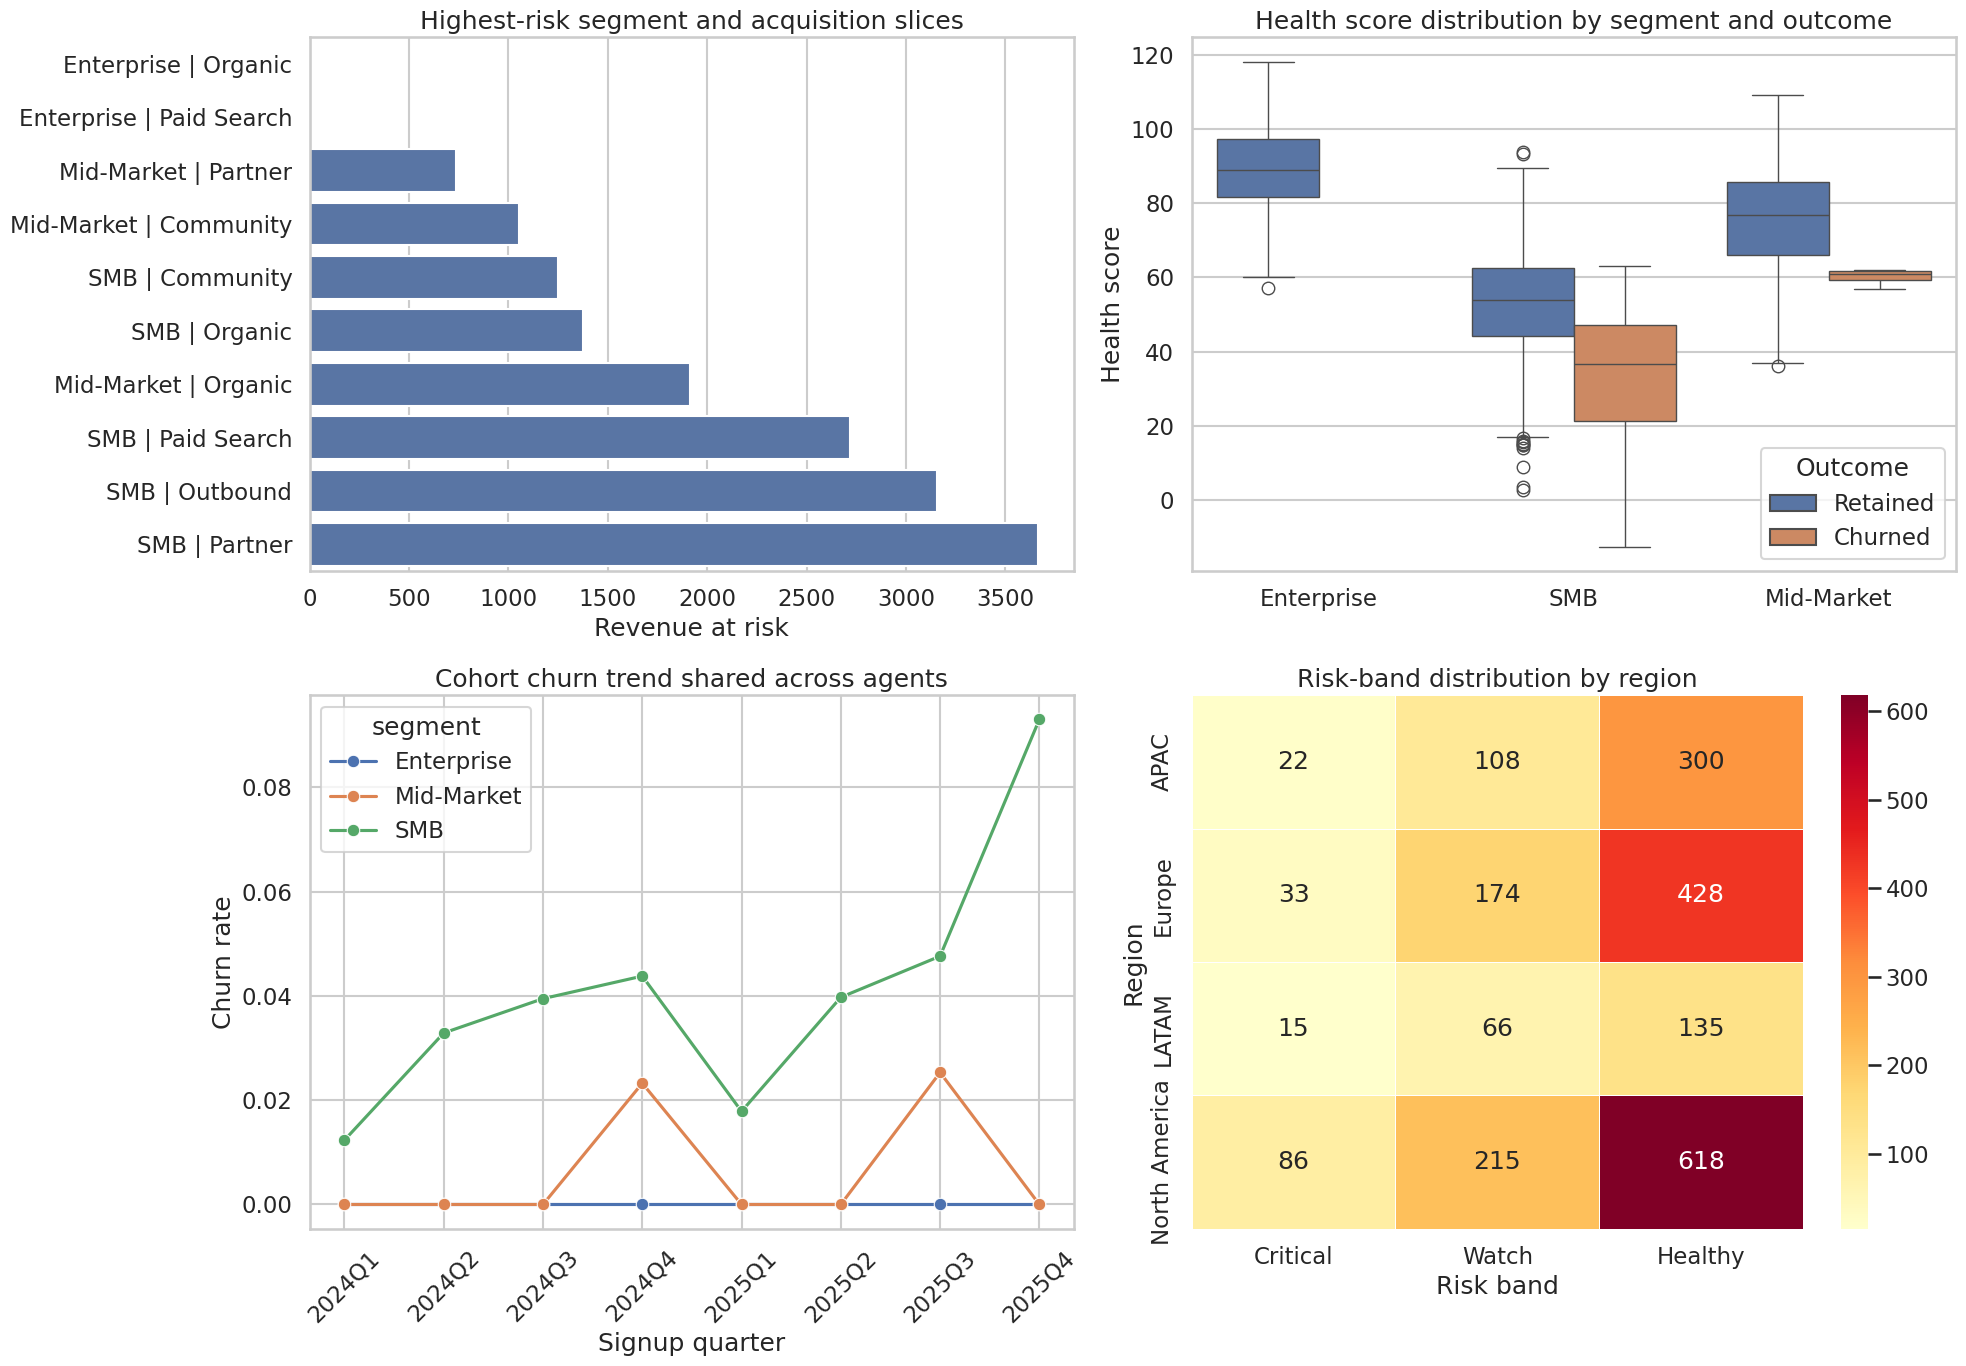

In [3]:
segment_channel = customers.groupby(["segment", "acquisition_channel"], as_index=False).agg(
    customers=("customer_id", "count"),
    churn_rate=("is_churned", "mean"),
    avg_health_score=("health_score", "mean"),
    revenue_at_risk=("revenue_at_risk", "sum"),
)
segment_channel["slice_label"] = segment_channel["segment"] + " | " + segment_channel["acquisition_channel"]
top_slices = segment_channel.sort_values("revenue_at_risk", ascending=False).head(10).sort_values("revenue_at_risk")

cohort_view = customers.groupby(["cohort_quarter", "segment"], as_index=False).agg(
    customers=("customer_id", "count"),
    churn_rate=("is_churned", "mean"),
    avg_health_score=("health_score", "mean"),
)
risk_band_region = customers.groupby(["region", "risk_band"]).size().unstack(fill_value=0)
risk_band_region = risk_band_region.reindex(columns=["Critical", "Watch", "Healthy"], fill_value=0)

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
sns.barplot(data=top_slices, x="revenue_at_risk", y="slice_label", color="#4C72B0", ax=axes[0, 0])
axes[0, 0].set(title="Highest-risk segment and acquisition slices", xlabel="Revenue at risk", ylabel="")

sns.boxplot(data=customers, x="segment", y="health_score", hue="churn_label", ax=axes[0, 1])
axes[0, 1].set(title="Health score distribution by segment and outcome", xlabel="", ylabel="Health score")
axes[0, 1].legend(title="Outcome")

sns.lineplot(data=cohort_view, x="cohort_quarter", y="churn_rate", hue="segment", marker="o", ax=axes[1, 0])
axes[1, 0].set(title="Cohort churn trend shared across agents", xlabel="Signup quarter", ylabel="Churn rate")
axes[1, 0].tick_params(axis="x", rotation=45)

sns.heatmap(risk_band_region, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=0.5, ax=axes[1, 1])
axes[1, 1].set(title="Risk-band distribution by region", xlabel="Risk band", ylabel="Region")

plt.tight_layout()
display(top_slices[["slice_label", "customers", "churn_rate", "avg_health_score", "revenue_at_risk"]].round(2))

## Agent Council Run

The notebook now hands the shared state to the agent council. Each agent gets the same dataframe and summaries, but each responds according to a different role. This is the core prototype idea: multiple notebook-native perspectives rather than one generic assistant response.

In [4]:
turns, context = prototype.run(customers, seed=SEED)
turns_df = turns_to_frame(turns)
priority_df = priority_board(turns)
next_cells_df = planned_notebook_cells(turns)

display(metric_cards([
    {"title": "Run mode", "value": context.get('run_mode', 'live_ai').replace('_', ' ').title(), "note": "The council output below was generated directly by the live model."},
    {"title": "Top priority", "value": priority_df.iloc[0]['agent'], "note": priority_df.iloc[0]['focus']},
    {"title": "Highest score", "value": f"{priority_df.iloc[0]['priority_score']:.2f}", "note": priority_df.iloc[0]['urgency_label']},
    {"title": "Writer ready", "value": "Yes", "note": "A notebook narrative update has already been drafted by the model."},
]))
display(agent_cards(turns_df))
display(priority_df)
display(callout("Writer draft", writer_note(turns), tone="info"))

,agent,focus,action,urgency,confidence,priority_score,urgency_label
0,Reviewer,SMB Cohort Validation and Channel Correlation,Prioritize the Reproducer's verification of data consistency and the Critic's request for a statistical significance test on the 2025Q4 ...,5,0.98,4.90,Critical
1,Analyst,SMB Cohort Decay Analysis,Cross-reference the 2025Q4 SMB cohort against acquisition channels to determine if the churn spike is isolated to a specific channel (e....,5,0.95,4.75,Critical
2,Reproducer,Execution Integrity and Data Consistency,Verify that the 'weakest_cohort' metrics were derived from the same filtered state as the 'overall_metrics' and ensure that the proposed...,4,1.00,4.00,High
3,Writer,Narrative Synthesis of SMB Cohort Volatility,Draft a transitional prose section that highlights the 2025Q4 SMB cohort as a primary area of concern while explicitly framing the curre...,3,0.90,2.70,Medium
4,Critic,SMB Cohort Validity and Sample Size,"Request a statistical significance test (e.g., Chi-squared or Z-test) to determine if the 2025Q4 SMB churn rate is statistically differe...",3,0.88,2.64,Medium


,cell_title,owner_agent,goal,priority_score
0,Intervention analysis for high-risk slice,Analyst,Cross-reference the 2025Q4 SMB cohort against acquisition channels to determine if the churn spike is isolated to a specific channel (e....,4.75
1,Reproducibility fingerprint cell,Reproducer,Verify that the 'weakest_cohort' metrics were derived from the same filtered state as the 'overall_metrics' and ensure that the proposed...,4.00
2,Narrative checkpoint note,Writer,Draft a transitional prose section that highlights the 2025Q4 SMB cohort as a primary area of concern while explicitly framing the curre...,2.70
3,Robustness and missing-data appendix,Critic,"Request a statistical significance test (e.g., Chi-squared or Z-test) to determine if the 2025Q4 SMB churn rate is statistically differe...",2.64


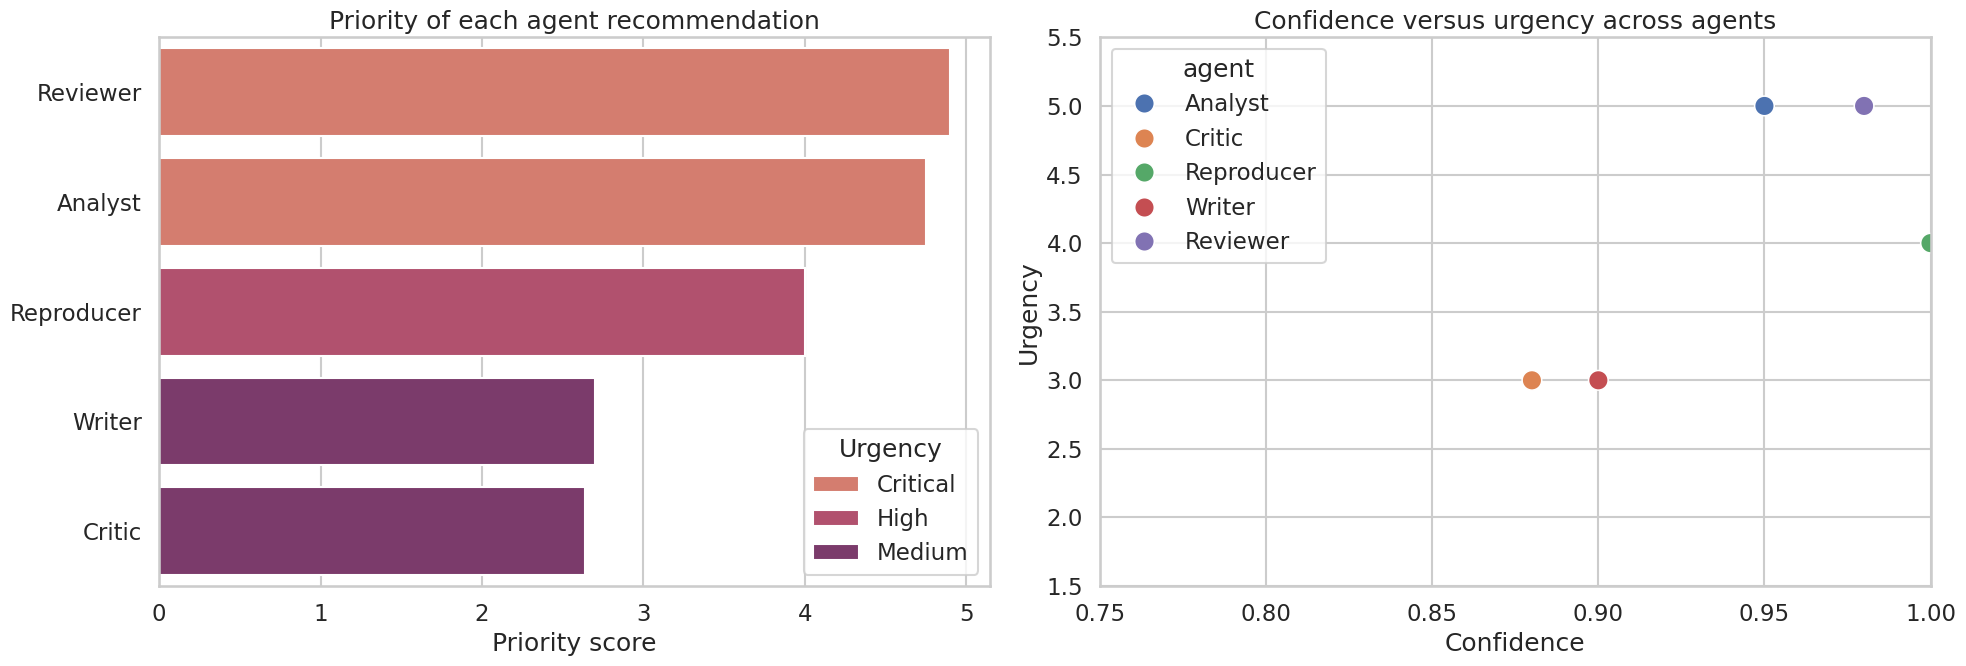

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
sns.barplot(data=priority_df, x="priority_score", y="agent", hue="urgency_label", dodge=False, palette="flare", ax=axes[0])
axes[0].set(title="Priority of each agent recommendation", xlabel="Priority score", ylabel="")
axes[0].legend(title="Urgency")

sns.scatterplot(data=turns_df, x="confidence", y="urgency", hue="agent", s=200, ax=axes[1])
axes[1].set(title="Confidence versus urgency across agents", xlabel="Confidence", ylabel="Urgency")
axes[1].set_xlim(0.75, 1.0)
axes[1].set_ylim(1.5, 5.5)

plt.tight_layout()
display(callout(
    "Planned notebook backlog",
    "The council output is not just a conversation transcript. It becomes a concrete ranked list of new notebook cells that can be inserted next.",
    tone="info",
))
display(next_cells_df)

## What This Prototype Covers

This notebook demonstrates an AI-native multi-agent notebook prototype: shared data state, role-specialized reasoning, a live model-backed council that drives each decision, and a styled interface that presents the experience as a polished product concept rather than raw notebook plumbing.